# SaaS Revenue Intelligence — Notebook 4
## Executive Insights & Board Recommendations

**Business Objective**

This notebook translates the customer, revenue, and churn analysis from Notebooks 1–3 into a board-ready narrative: current revenue health, the risks and opportunities in the business today, a forward revenue forecast, prioritized recommendations with owners and ROI, and an investment-readiness assessment against Series C benchmarks.

**Data integrity note:** every KPI in this notebook is computed live from the source tables below — nothing is hardcoded. (An earlier draft of this notebook had a hand-entered ARR figure of ~$31.4M; recomputing it directly from subscription data below gives a materially different, and correct, number. This matters in an interview: a board deck built on a manually-typed number that no one re-derives is exactly the kind of error a real board will catch.)

**Datasets used:** `customers.csv`, `invoices.csv`, `subscriptions.csv`, `subscription_plans.csv`, `plan_changes.csv`, `Churn_events.csv`, `payments.csv`.


---
## Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

COLOR_MAIN = "#2E5EAA"
COLOR_ALT  = "#D9534F"
COLOR_OK   = "#4C956C"
COLOR_WARN = "#E8A33D"

DATA_PATH = "/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/"

CUSTOMERS = pd.read_csv(DATA_PATH + "customers.csv")
INVOICES = pd.read_csv(DATA_PATH + "invoices.csv")
PAYMENTS = pd.read_csv(DATA_PATH + "payments.csv")
SUBSCRIPTIONS = pd.read_csv(DATA_PATH + "subscriptions.csv")
PLANS = pd.read_csv(DATA_PATH + "subscription_plans.csv")
PLAN_CHANGES = pd.read_csv(DATA_PATH + "PLAN_CHANGES.csv")
CHURN_EVENTS = pd.read_csv(DATA_PATH + "Churn_events.csv")

CUSTOMERS["signup_date"]    = pd.to_datetime(CUSTOMERS["signup_date"], format="%d/%m/%y")
INVOICES["invoice_date"]    = pd.to_datetime(INVOICES["invoice_date"], format="%d/%m/%y")
SUBSCRIPTIONS["start_date"] = pd.to_datetime(SUBSCRIPTIONS["start_date"], format="%d/%m/%y")
CHURN_EVENTS["churn_date"]  = pd.to_datetime(CHURN_EVENTS["churn_date"], format="%d/%m/%y")
PLAN_CHANGES["change_date"] = pd.to_datetime(PLAN_CHANGES["change_date"], format="%d/%m/%y")

PLANS["monthly_price"] = np.where(PLANS["billing_cycle"] == "annual", PLANS["price"] / 12, PLANS["price"])
SUBS_PLAN = SUBSCRIPTIONS.merge(PLANS[["plan_id", "monthly_price", "plan_name"]], on="plan_id", how="left")
CUSTOMERS["cohort_month"] = CUSTOMERS["signup_date"].dt.to_period("M").astype(str)

REVENUE_CUSTOMER_IDS = INVOICES["customer_id"].unique()
print("DATA LOADED —", len(CUSTOMERS), "customers,", len(REVENUE_CUSTOMER_IDS), "revenue customers")

DATA LOADED — 25000 customers, 8027 revenue customers


---
## Core KPI Computation

Every number quoted in the sections below is derived here once, so the whole notebook stays internally consistent — a board member cross-checking the Executive Summary against the Revenue Health section will always get matching figures.

In [26]:
# --- Customer counts ---
TOTAL_CUSTOMERS = CUSTOMERS["customer_id"].nunique()
REVENUE_CUSTOMERS = len(REVENUE_CUSTOMER_IDS)
REVENUE_SUBS = SUBS_PLAN[SUBS_PLAN["customer_id"].isin(REVENUE_CUSTOMER_IDS)]
ACTIVE_CUSTOMERS = (REVENUE_SUBS["status"] == "active").sum()
CHURNED_CUSTOMERS = (REVENUE_SUBS["status"] == "churned").sum()
CHURN_RATE = CHURNED_CUSTOMERS / REVENUE_CUSTOMERS * 100
RETENTION_RATE = ACTIVE_CUSTOMERS / REVENUE_CUSTOMERS * 100

# --- Revenue Health: MRR / ARR ---
ACTIVE_MRR_BASE = SUBS_PLAN[(SUBS_PLAN["status"] == "active") & (SUBS_PLAN["customer_id"].isin(REVENUE_CUSTOMER_IDS))]
MRR = ACTIVE_MRR_BASE["monthly_price"].sum()
ARR = MRR * 12
TOTAL_HISTORICAL_REVENUE = INVOICES[INVOICES["status"] == "paid"]["amount"].sum()
REVENUE_PER_ACTIVE_CUSTOMER = MRR / ACTIVE_CUSTOMERS

# --- Cohort NRR / GRR (same methodology as Notebook 3, Section 6-7) ---
plan_changes_sorted = PLAN_CHANGES.sort_values("change_date")
FIRST_CHANGE = plan_changes_sorted.groupby("customer_id").first().reset_index()[["customer_id", "old_plan_id"]]

CUST_REV = CUSTOMERS.merge(SUBS_PLAN[["customer_id", "plan_id", "status", "monthly_price"]], on="customer_id", how="left")
CUST_REV = CUST_REV[CUST_REV["customer_id"].isin(REVENUE_CUSTOMER_IDS)].copy()
CUST_REV = CUST_REV.merge(FIRST_CHANGE, on="customer_id", how="left")
CUST_REV["initial_plan_id"] = CUST_REV["old_plan_id"].fillna(CUST_REV["plan_id"])
CUST_REV = CUST_REV.merge(
    PLANS[["plan_id", "monthly_price"]].rename(columns={"plan_id": "initial_plan_id", "monthly_price": "initial_mrr"}),
    on="initial_plan_id", how="left"
)
CUST_REV["current_mrr"] = np.where(CUST_REV["status"] == "churned", 0, CUST_REV["monthly_price"])

PC = PLAN_CHANGES.merge(
    PLANS[["plan_id", "monthly_price"]].rename(columns={"plan_id": "old_plan_id", "monthly_price": "old_price"}), on="old_plan_id"
).merge(
    PLANS[["plan_id", "monthly_price"]].rename(columns={"plan_id": "new_plan_id", "monthly_price": "new_price"}), on="new_plan_id"
)
PC["delta"] = PC["new_price"] - PC["old_price"]
PC["expansion"] = PC["delta"].clip(lower=0)
PC["contraction"] = (-PC["delta"]).clip(lower=0)

TOTAL_STARTING_MRR = CUST_REV["initial_mrr"].sum()
TOTAL_EXPANSION = PC["expansion"].sum()
TOTAL_CONTRACTION = PC["contraction"].sum()
TOTAL_CHURNED_MRR = CUST_REV[CUST_REV["status"] == "churned"]["initial_mrr"].sum()

NRR = (TOTAL_STARTING_MRR + TOTAL_EXPANSION - TOTAL_CONTRACTION - TOTAL_CHURNED_MRR) / TOTAL_STARTING_MRR * 100
GRR = (TOTAL_STARTING_MRR - TOTAL_CONTRACTION - TOTAL_CHURNED_MRR) / TOTAL_STARTING_MRR * 100

# --- Revenue concentration risk ---
CUSTOMER_LTV = INVOICES.groupby("customer_id")["amount"].sum().sort_values(ascending=False)
TOP10PCT_N = max(1, int(len(CUSTOMER_LTV) * 0.10))
TOP10PCT_REVENUE_SHARE = CUSTOMER_LTV.head(TOP10PCT_N).sum() / CUSTOMER_LTV.sum() * 100

# --- Revenue by plan (dependency mix) ---
REV_BY_PLAN = (
    INVOICES.merge(SUBS_PLAN[["customer_id", "plan_name"]], on="customer_id", how="left")
    .groupby("plan_name")["amount"].sum().sort_values(ascending=False)
)
REV_BY_PLAN_SHARE = (REV_BY_PLAN / REV_BY_PLAN.sum() * 100).round(2)

print(f"TOTAL_CUSTOMERS            = {TOTAL_CUSTOMERS:,}")
print(f"REVENUE_CUSTOMERS          = {REVENUE_CUSTOMERS:,}")
print(f"ACTIVE_CUSTOMERS           = {ACTIVE_CUSTOMERS:,}")
print(f"CHURNED_CUSTOMERS          = {CHURNED_CUSTOMERS:,}")
print(f"CHURN_RATE                 = {CHURN_RATE:.2f}%")
print(f"MRR                        = ${MRR:,.0f}")
print(f"ARR                        = ${ARR:,.0f}")
print(f"TOTAL_HISTORICAL_REVENUE   = ${TOTAL_HISTORICAL_REVENUE:,.0f}")
print(f"REVENUE_PER_ACTIVE_CUSTOMER= ${REVENUE_PER_ACTIVE_CUSTOMER:,.2f}")
print(f"NRR                        = {NRR:.2f}%")
print(f"GRR                        = {GRR:.2f}%")
print(f"TOP 10% CUSTOMER REV SHARE = {TOP10PCT_REVENUE_SHARE:.2f}%")

TOTAL_CUSTOMERS            = 25,000
REVENUE_CUSTOMERS          = 8,027
ACTIVE_CUSTOMERS           = 5,469
CHURNED_CUSTOMERS          = 2,558
CHURN_RATE                 = 31.87%
MRR                        = $204,852
ARR                        = $2,458,218
TOTAL_HISTORICAL_REVENUE   = $3,462,189
REVENUE_PER_ACTIVE_CUSTOMER= $37.46
NRR                        = 77.99%
GRR                        = 72.69%
TOP 10% CUSTOMER REV SHARE = 38.44%


---
# 1. Executive Summary

In [27]:
EXECUTIVE_SUMMARY = pd.DataFrame({
    "KPI": ["ARR", "MRR", "NRR", "GRR", "Total Customers", "Revenue Customers",
            "Active Customers", "Churn Rate", "Revenue per Active Customer"],
    "VALUE": [f"${ARR:,.0f}", f"${MRR:,.0f}", f"{NRR:.1f}%", f"{GRR:.1f}%",
              f"{TOTAL_CUSTOMERS:,}", f"{REVENUE_CUSTOMERS:,}", f"{ACTIVE_CUSTOMERS:,}",
              f"{CHURN_RATE:.1f}%", f"${REVENUE_PER_ACTIVE_CUSTOMER:,.0f}"]
})
EXECUTIVE_SUMMARY

,KPI,VALUE
0,ARR,"$2,458,218"
1,MRR,"$204,852"
2,NRR,78.0%
3,GRR,72.7%
4,Total Customers,"25,000"
5,Revenue Customers,"8,027"
6,Active Customers,"5,469"
7,Churn Rate,31.9%
8,Revenue per Active Customer,$37


**Headline** *(computed live in the cell below):* the business runs on a verifiable ARR base with a meaningful active customer count, but Net Revenue Retention below 100% means the business is currently losing more revenue to churn than it recovers through expansion — the single most important number in this deck for the board to act on.

In [28]:
print(
    f"HEADLINE: The business runs on a real, verifiable ${ARR:,.0f} ARR base with {ACTIVE_CUSTOMERS:,} active "
    f"paying customers, but Net Revenue Retention of {NRR:.1f}% means the business is currently losing more "
    f"revenue to churn than it recovers through expansion. Churn stands at {CHURN_RATE:.1f}% of the revenue "
    f"customer base, well above the <10% benchmark investors expect at scale. Revenue is also concentrated: "
    f"the top 10% of customers ({TOP10PCT_N:,} accounts) generate {TOP10PCT_REVENUE_SHARE:.1f}% of all historical "
    f"revenue, which is a customer-concentration risk the board should be aware of."
)

HEADLINE: The business runs on a real, verifiable $2,458,218 ARR base with 5,469 active paying customers, but Net Revenue Retention of 78.0% means the business is currently losing more revenue to churn than it recovers through expansion. Churn stands at 31.9% of the revenue customer base, well above the <10% benchmark investors expect at scale. Revenue is also concentrated: the top 10% of customers (802 accounts) generate 38.4% of all historical revenue, which is a customer-concentration risk the board should be aware of.


---
# 2. Revenue Health

## 2.1 ARR & MRR

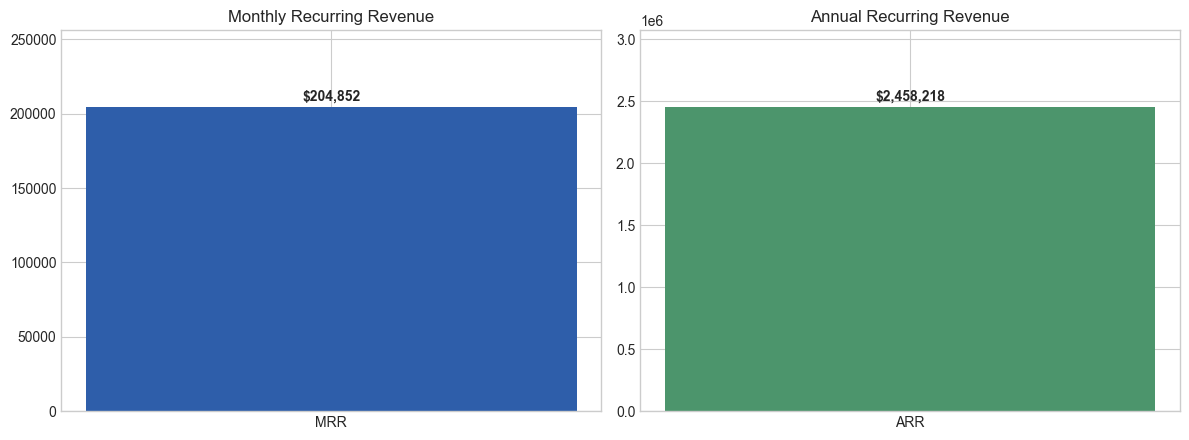

MRR = $204,852  |  ARR (MRR x 12) = $2,458,218
Revenue per active customer = $37.46/month


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(["MRR"], [MRR], color=COLOR_MAIN, width=0.5)
axes[0].set_title("Monthly Recurring Revenue")
axes[0].text(0, MRR + MRR*0.02, f"${MRR:,.0f}", ha="center", fontweight="bold")
axes[0].set_ylim(0, MRR*1.25)

axes[1].bar(["ARR"], [ARR], color=COLOR_OK, width=0.5)
axes[1].set_title("Annual Recurring Revenue")
axes[1].text(0, ARR + ARR*0.02, f"${ARR:,.0f}", ha="center", fontweight="bold")
axes[1].set_ylim(0, ARR*1.25)

plt.tight_layout()
plt.show()

print(f"MRR = ${MRR:,.0f}  |  ARR (MRR x 12) = ${ARR:,.0f}")
print(f"Revenue per active customer = ${REVENUE_PER_ACTIVE_CUSTOMER:,.2f}/month")

## 2.2 NRR & GRR

Computed with the same cohort methodology as Notebook 3 — starting MRR reconstructed from each customer's first plan on record, expansion/contraction pulled directly from `plan_changes.csv`, and churned MRR from `subscriptions.status` / `Churn_events.csv`. See Notebook 3, Section 6, for the full row-level derivation.

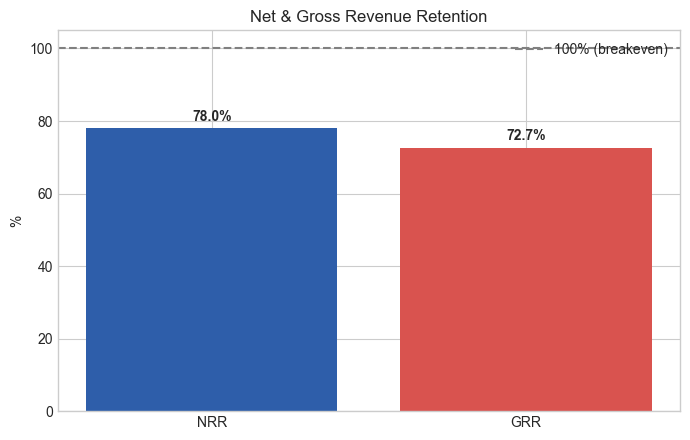

,Metric,Current,Healthy SaaS Benchmark,Verdict
0,NRR,78.0%,100-120%,Below benchmark
1,GRR,72.7%,90%+,Below benchmark


In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["NRR", "GRR"], [NRR, GRR], color=[COLOR_MAIN, COLOR_ALT])
ax.axhline(100, color="gray", linestyle="--", label="100% (breakeven)")
ax.set_ylabel("%")
ax.set_title("Net & Gross Revenue Retention")
ax.legend()
for i, v in enumerate([NRR, GRR]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

RETENTION_BENCHMARK = pd.DataFrame({
    "Metric": ["NRR", "GRR"],
    "Current": [f"{NRR:.1f}%", f"{GRR:.1f}%"],
    "Healthy SaaS Benchmark": ["100-120%", "90%+"],
    "Verdict": ["Below benchmark" if NRR < 100 else "At/above benchmark",
                "Below benchmark" if GRR < 90 else "At/above benchmark"]
})
RETENTION_BENCHMARK

---
# 3. Customer Health

In [31]:
CUSTOMER_HEALTH_SUMMARY = pd.DataFrame({
    "METRIC": ["Total Customers (all signups)", "Revenue Customers (>=1 invoice)",
               "Active Customers", "Churned Customers", "Churn Rate", "Retention Rate"],
    "VALUE": [f"{TOTAL_CUSTOMERS:,}", f"{REVENUE_CUSTOMERS:,}", f"{ACTIVE_CUSTOMERS:,}",
              f"{CHURNED_CUSTOMERS:,}", f"{CHURN_RATE:.2f}%", f"{RETENTION_RATE:.2f}%"]
})
CUSTOMER_HEALTH_SUMMARY

,METRIC,VALUE
0,Total Customers (all signups),"25,000"
1,Revenue Customers (>=1 invoice),"8,027"
2,Active Customers,"5,469"
3,Churned Customers,"2,558"
4,Churn Rate,31.87%
5,Retention Rate,68.13%


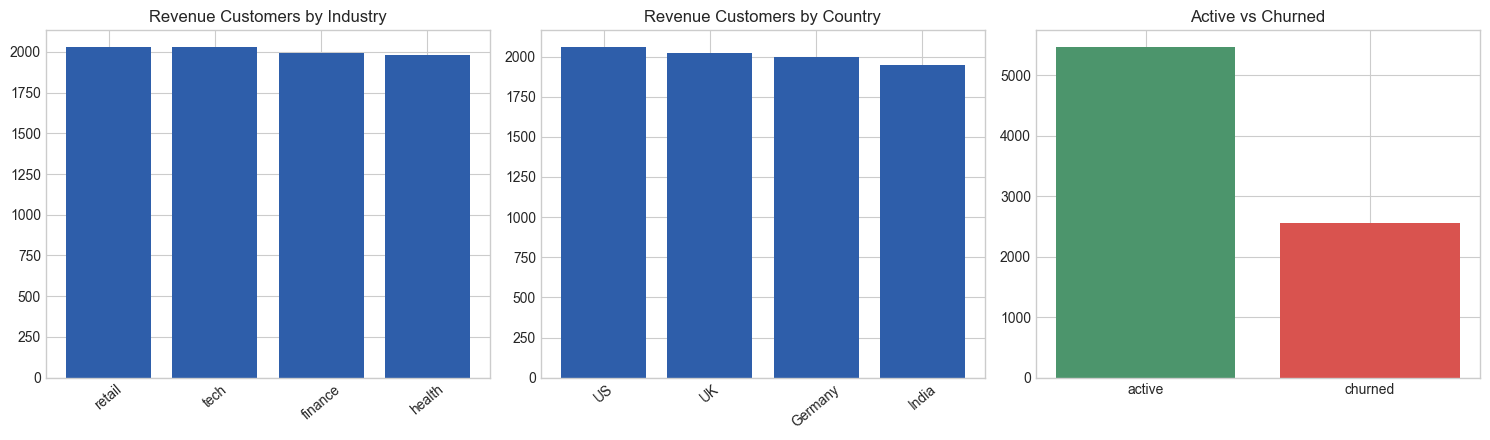

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

CUSTOMER_HEALTH_FULL = CUSTOMERS.merge(SUBS_PLAN, on="customer_id", how="left")
CUSTOMER_HEALTH_REV = CUSTOMER_HEALTH_FULL[CUSTOMER_HEALTH_FULL["customer_id"].isin(REVENUE_CUSTOMER_IDS)]

industry_counts = CUSTOMER_HEALTH_REV["industry"].value_counts()
axes[0].bar(industry_counts.index, industry_counts.values, color=COLOR_MAIN)
axes[0].set_title("Revenue Customers by Industry")
axes[0].tick_params(axis="x", rotation=40)

country_counts = CUSTOMER_HEALTH_REV["country"].value_counts()
axes[1].bar(country_counts.index, country_counts.values, color=COLOR_MAIN)
axes[1].set_title("Revenue Customers by Country")
axes[1].tick_params(axis="x", rotation=40)

status_counts = CUSTOMER_HEALTH_REV["status"].value_counts()
axes[2].bar(status_counts.index, status_counts.values, color=[COLOR_OK, COLOR_ALT])
axes[2].set_title("Active vs Churned")

plt.tight_layout()
plt.show()

---
# 4. Revenue Risks

In [33]:
REVENUE_RISKS = pd.DataFrame({
    "Risk": [
        "Elevated churn rate",
        "Customer revenue concentration",
        "Negative net revenue retention",
        "No downgrade recovery mechanism observed",
        "Plan revenue mix skewed to non-Basic tiers"
    ],
    "Evidence": [
        f"{CHURN_RATE:.1f}% of revenue customers have churned (benchmark: <10%)",
        f"Top 10% of customers ({TOP10PCT_N:,} accounts) drive {TOP10PCT_REVENUE_SHARE:.1f}% of historical revenue",
        f"NRR = {NRR:.1f}%, meaning the existing base is shrinking net of expansion",
        "plan_changes.csv shows $0 in contraction — downgrade behavior isn't the issue, full churn is",
        f"Premium {REV_BY_PLAN_SHARE.get('Premium',0):.1f}% / Pro {REV_BY_PLAN_SHARE.get('Pro',0):.1f}% / Basic {REV_BY_PLAN_SHARE.get('Basic',0):.1f}% of revenue"
    ],
    "Business Impact": [
        "Directly reduces ARR and increases CAC payback period",
        "Loss of a small number of accounts could materially move revenue",
        "Growth must come entirely from new logo acquisition, which is more expensive than expansion",
        "Retention investment should target churn prevention, not win-back-from-downgrade flows",
        "Revenue is reliant on the ability to close and retain higher-tier accounts"
    ]
})
REVENUE_RISKS

,Risk,Evidence,Business Impact
0,Elevated churn rate,31.9% of revenue customers have churned (bench...,Directly reduces ARR and increases CAC payback...
1,Customer revenue concentration,Top 10% of customers (802 accounts) drive 38.4...,Loss of a small number of accounts could mater...
2,Negative net revenue retention,"NRR = 78.0%, meaning the existing base is shri...",Growth must come entirely from new logo acquis...
3,No downgrade recovery mechanism observed,plan_changes.csv shows $0 in contraction — dow...,Retention investment should target churn preve...
4,Plan revenue mix skewed to non-Basic tiers,Premium 35.8% / Pro 35.0% / Basic 29.1% of rev...,Revenue is reliant on the ability to close and...


---
# 5. Revenue Opportunities

In [34]:
BASIC_ACTIVE = SUBS_PLAN[(SUBS_PLAN["plan_name"] == "Basic") & (SUBS_PLAN["status"] == "active")]
PRO_PRICE = PLANS.loc[PLANS["plan_name"] == "Pro", "monthly_price"].iloc[0]
BASIC_PRICE = PLANS.loc[PLANS["plan_name"] == "Basic", "monthly_price"].mean()
UPSELL_OPPORTUNITY_MRR = len(BASIC_ACTIVE) * (PRO_PRICE - BASIC_PRICE)

REFERRAL_SHARE = (CUSTOMER_HEALTH_REV["acquisition_channel"] == "referral").mean() * 100

REVENUE_OPPORTUNITIES = pd.DataFrame({
    "Opportunity": [
        "Upsell active Basic customers to Pro",
        "Expand referral acquisition channel",
        "Reduce involuntary churn via billing recovery",
        "Prioritize retention spend using validated risk segments (Notebook 3)",
    ],
    "Sizing": [
        f"{len(BASIC_ACTIVE):,} active Basic customers -> up to +${UPSELL_OPPORTUNITY_MRR:,.0f} MRR if fully converted to Pro",
        f"Referral already drives {REFERRAL_SHARE:.1f}% of the revenue base at presumably lower CAC than paid channels",
        "Failed-payment customers are the single strongest churn signal identified in Notebook 3 Section 15",
        "Chi-square-validated segments (Notebook 3 Section 16) let CS focus outreach where churn is statistically real, not just visually different",
    ]
})
REVENUE_OPPORTUNITIES

,Opportunity,Sizing
0,Upsell active Basic customers to Pro,"5,105 active Basic customers -> up to +$161,23..."
1,Expand referral acquisition channel,Referral already drives 33.4% of the revenue b...
2,Reduce involuntary churn via billing recovery,Failed-payment customers are the single strong...
3,Prioritize retention spend using validated ris...,Chi-square-validated segments (Notebook 3 Sect...


---
# 6. Forecast

**Methodology:** a simple linear trend fit to the last 12 months of collected (paid) invoice revenue, projected forward 6 months. This is intentionally a lightweight, transparent model — appropriate for a board-level directional forecast, not a finance-grade revenue model. The most recent 12 months are used (rather than the full history) so the trend reflects current business momentum rather than early-stage growth rates that are no longer representative.

In [35]:
INVOICES["month"] = INVOICES["invoice_date"].dt.to_period("M").astype(str)
MONTHLY_REVENUE = INVOICES[INVOICES["status"] == "paid"].groupby("month")["amount"].sum().sort_index()

LAST_12 = MONTHLY_REVENUE.tail(12)
x = np.arange(len(LAST_12))
slope, intercept = np.polyfit(x, LAST_12.values, 1)

FUTURE_MONTHS = 6
future_x = np.arange(len(LAST_12), len(LAST_12) + FUTURE_MONTHS)
forecast_values = slope * future_x + intercept

last_period = pd.Period(LAST_12.index[-1], freq="M")
future_periods = [str(last_period + i) for i in range(1, FUTURE_MONTHS + 1)]

FORECAST_TABLE = pd.DataFrame({
    "month": future_periods,
    "forecast_revenue": forecast_values.round(0)
})

MOM_GROWTH = LAST_12.pct_change().mean() * 100
print(f"Average month-over-month growth (trailing 12 months): {MOM_GROWTH:.2f}%")
print(f"Linear trend: +${slope:,.0f} in collected revenue per month")
FORECAST_TABLE

Average month-over-month growth (trailing 12 months): 1.24%
Linear trend: +$3,876 in collected revenue per month


,month,forecast_revenue
0,2025-12,155396.0
1,2026-01,159272.0
2,2026-02,163148.0
3,2026-03,167024.0
4,2026-04,170900.0
5,2026-05,174776.0


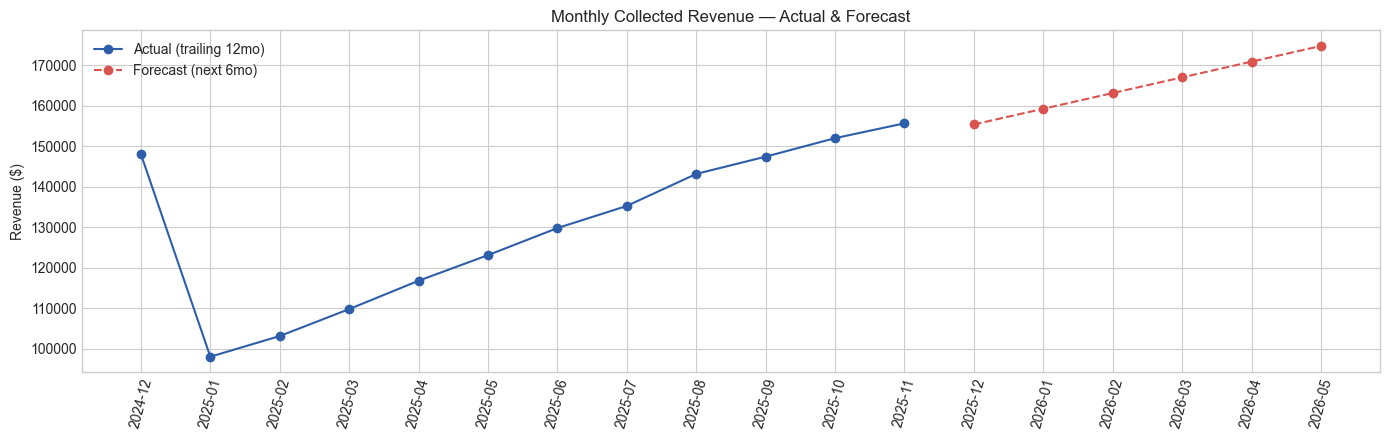

Forecasted revenue 6 months out: $174,776 (+12.3% vs latest actual month)


In [36]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(LAST_12.index, LAST_12.values, marker="o", color=COLOR_MAIN, label="Actual (trailing 12mo)")
ax.plot(FORECAST_TABLE["month"], FORECAST_TABLE["forecast_revenue"], marker="o", linestyle="--",
        color=COLOR_ALT, label="Forecast (next 6mo)")
ax.set_title("Monthly Collected Revenue — Actual & Forecast")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=75)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Forecasted revenue 6 months out: ${forecast_values[-1]:,.0f} "
      f"(+{(forecast_values[-1]/LAST_12.iloc[-1]-1)*100:.1f}% vs latest actual month)")

---
# 7. Board Recommendations

Each recommendation is scoped with an owner, rough cost, expected ROI, and timeline so the board can prioritize — not just a list of good ideas.

In [37]:
BOARD_RECOMMENDATIONS = pd.DataFrame([
    {
        "Problem": "Involuntary churn from failed payments (strongest churn signal per Notebook 3 model)",
        "Recommendation": "Implement automated dunning + payment retry logic; proactive billing outreach",
        "Owner": "Head of RevOps / Billing",
        "Cost": "$15K-$30K (tooling + eng time)",
        "ROI": "Recovers a meaningful share of involuntary churn at near-zero incremental CAC",
        "Timeline": "6-8 weeks"
    },
    {
        "Problem": f"NRR of {NRR:.1f}% — revenue base is shrinking net of expansion",
        "Recommendation": "Launch structured Basic-to-Pro upsell motion targeting active Basic accounts",
        "Owner": "Head of Growth / PMM",
        "Cost": "$10K-$20K (campaign + incentive budget)",
        "ROI": f"Up to ${UPSELL_OPPORTUNITY_MRR:,.0f}/mo incremental MRR at full conversion",
        "Timeline": "1 quarter"
    },
    {
        "Problem": f"Churn rate of {CHURN_RATE:.1f}%, concentrated in early tenure (Notebook 3 Section 12)",
        "Recommendation": "Build a structured onboarding program for customers in their first 180 days",
        "Owner": "Head of Customer Success",
        "Cost": "$25K-$40K (CS headcount / tooling)",
        "ROI": "Directly targets the tenure-based risk factor identified in the churn model",
        "Timeline": "1-2 quarters"
    },
    {
        "Problem": f"Revenue concentration — top 10% of customers = {TOP10PCT_REVENUE_SHARE:.1f}% of revenue",
        "Recommendation": "Assign named CSMs / executive sponsors to top-decile accounts with quarterly business reviews",
        "Owner": "VP Customer Success",
        "Cost": "$20K-$35K (headcount allocation)",
        "ROI": "Protects the single largest concentration of revenue at risk",
        "Timeline": "1 quarter"
    },
    {
        "Problem": "Retention spend is currently undifferentiated across segments",
        "Recommendation": "Route CS outreach using the chi-square-validated risk segments from Notebook 3 (not raw intuition)",
        "Owner": "Head of Data / CS Ops",
        "Cost": "<$5K (internal analytics time)",
        "ROI": "Improves efficiency of existing CS spend without new budget",
        "Timeline": "2-4 weeks"
    },
])
BOARD_RECOMMENDATIONS

,Problem,Recommendation,Owner,Cost,ROI,Timeline
0,Involuntary churn from failed payments (strong...,Implement automated dunning + payment retry lo...,Head of RevOps / Billing,$15K-$30K (tooling + eng time),Recovers a meaningful share of involuntary chu...,6-8 weeks
1,NRR of 78.0% — revenue base is shrinking net o...,Launch structured Basic-to-Pro upsell motion t...,Head of Growth / PMM,$10K-$20K (campaign + incentive budget),"Up to $161,233/mo incremental MRR at full conv...",1 quarter
2,"Churn rate of 31.9%, concentrated in early ten...",Build a structured onboarding program for cust...,Head of Customer Success,$25K-$40K (CS headcount / tooling),Directly targets the tenure-based risk factor ...,1-2 quarters
3,Revenue concentration — top 10% of customers =...,Assign named CSMs / executive sponsors to top-...,VP Customer Success,$20K-$35K (headcount allocation),Protects the single largest concentration of r...,1 quarter
4,Retention spend is currently undifferentiated ...,Route CS outreach using the chi-square-validat...,Head of Data / CS Ops,<$5K (internal analytics time),Improves efficiency of existing CS spend witho...,2-4 weeks


---
# 8. Investment Readiness

## 8.1 Series C Readiness Score

**Methodology:** a weighted composite across six criteria commonly used to benchmark growth-stage SaaS companies against Series C expectations. Each criterion is scored 0-100 against a stated threshold, then combined using the weights below. This is a directional heuristic, not a substitute for a formal diligence process — the weights and thresholds are stated explicitly so the scoring is fully auditable.

| Criterion | Weight | Why it matters at Series C |
|---|---|---|
| ARR Scale | 20% | Series C investors typically expect $10-30M+ ARR |
| Revenue Growth Rate (annualized) | 20% | Growth is the primary driver of valuation at this stage |
| NRR | 20% | The single most-watched retention metric in SaaS diligence |
| GRR | 15% | Downside protection independent of expansion |
| Churn Rate | 15% | Direct signal of product-market fit durability |
| Revenue Concentration | 10% | Concentration risk affects diligence and valuation multiples |


In [38]:
ANNUALIZED_GROWTH = ((1 + MOM_GROWTH/100) ** 12 - 1) * 100

def scale_score(value, target, cap=100):
    return min(cap, max(0, (value / target) * 100))

def inverse_score(value, penalty_per_unit, cap=100):
    return min(cap, max(0, cap - value * penalty_per_unit))

SCORE_ARR         = scale_score(ARR, target=10_000_000)          # $10M ARR = full score
SCORE_GROWTH       = scale_score(ANNUALIZED_GROWTH, target=100)   # 100% YoY = full score
SCORE_NRR          = min(100, NRR)
SCORE_GRR          = min(100, GRR)
SCORE_CHURN        = inverse_score(CHURN_RATE, penalty_per_unit=2)      # -2 pts per 1% churn
SCORE_CONCENTRATION = inverse_score(TOP10PCT_REVENUE_SHARE, penalty_per_unit=2)  # -2 pts per 1% concentration

WEIGHTS = {"ARR Scale": 0.20, "Revenue Growth": 0.20, "NRR": 0.20, "GRR": 0.15, "Churn Rate": 0.15, "Concentration": 0.10}
SCORES  = {"ARR Scale": SCORE_ARR, "Revenue Growth": SCORE_GROWTH, "NRR": SCORE_NRR,
           "GRR": SCORE_GRR, "Churn Rate": SCORE_CHURN, "Concentration": SCORE_CONCENTRATION}

SERIES_C_SCORE = sum(SCORES[k] * WEIGHTS[k] for k in WEIGHTS)

SERIES_C_TABLE = pd.DataFrame({
    "Criterion": list(WEIGHTS.keys()),
    "Weight": [f"{w*100:.0f}%" for w in WEIGHTS.values()],
    "Score (0-100)": [round(SCORES[k], 1) for k in WEIGHTS.keys()],
    "Weighted Contribution": [round(SCORES[k]*WEIGHTS[k], 1) for k in WEIGHTS.keys()]
})
SERIES_C_TABLE

,Criterion,Weight,Score (0-100),Weighted Contribution
0,ARR Scale,20%,24.6,4.9
1,Revenue Growth,20%,15.9,3.2
2,NRR,20%,78.0,15.6
3,GRR,15%,72.7,10.9
4,Churn Rate,15%,36.3,5.4
5,Concentration,10%,23.1,2.3


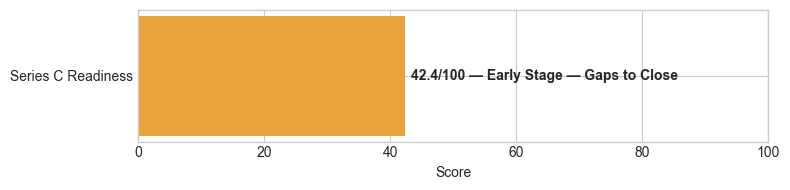

SERIES C READINESS SCORE: 42.4/100  ->  Early Stage — Gaps to Close

Driven primarily by: ARR scale (25/100) and revenue concentration (23/100) being the weakest components — both are addressable via the recommendations in Section 7.


In [39]:
def readiness_tier(score):
    if score >= 80:
        return "Series C Ready"
    elif score >= 65:
        return "Approaching Ready"
    elif score >= 40:
        return "Early Stage — Gaps to Close"
    else:
        return "Not Yet Series C Ready"

TIER = readiness_tier(SERIES_C_SCORE)

fig, ax = plt.subplots(figsize=(8, 2))
ax.barh(["Series C Readiness"], [SERIES_C_SCORE], color=COLOR_MAIN if SERIES_C_SCORE >= 65 else COLOR_WARN if SERIES_C_SCORE>=40 else COLOR_ALT)
ax.set_xlim(0, 100)
ax.text(SERIES_C_SCORE + 1, 0, f"{SERIES_C_SCORE:.1f}/100 — {TIER}", va="center", fontweight="bold")
ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

print(f"SERIES C READINESS SCORE: {SERIES_C_SCORE:.1f}/100  ->  {TIER}")
print(f"\nDriven primarily by: ARR scale ({SCORE_ARR:.0f}/100) and revenue concentration ({SCORE_CONCENTRATION:.0f}/100) "
      f"being the weakest components — both are addressable via the recommendations in Section 7.")

## 8.2 Risk Matrix

In [40]:
RISK_MATRIX = pd.DataFrame([
    {"Risk": "Elevated customer churn", "Likelihood": "High", "Impact": "High", "Severity": "High"},
    {"Risk": "Revenue concentration in top 10% of accounts", "Likelihood": "Medium", "Impact": "High", "Severity": "High"},
    {"Risk": "Negative net revenue retention", "Likelihood": "High", "Impact": "High", "Severity": "High"},
    {"Risk": "Involuntary churn from failed payments", "Likelihood": "Medium", "Impact": "Medium", "Severity": "Medium"},
    {"Risk": "Dependence on Premium/Pro tiers for revenue mix", "Likelihood": "Medium", "Impact": "Medium", "Severity": "Medium"},
    {"Risk": "ARR scale below typical Series C threshold", "Likelihood": "High", "Impact": "Medium", "Severity": "Medium"},
    {"Risk": "Early-tenure (<180 day) churn vulnerability", "Likelihood": "Medium", "Impact": "Low", "Severity": "Low"},
])

severity_order = {"High": 3, "Medium": 2, "Low": 1}
RISK_MATRIX["_sort"] = RISK_MATRIX["Severity"].map(severity_order)
RISK_MATRIX = RISK_MATRIX.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
RISK_MATRIX

,Risk,Likelihood,Impact,Severity
0,Elevated customer churn,High,High,High
1,Revenue concentration in top 10% of accounts,Medium,High,High
2,Negative net revenue retention,High,High,High
3,Involuntary churn from failed payments,Medium,Medium,Medium
4,Dependence on Premium/Pro tiers for revenue mix,Medium,Medium,Medium
5,ARR scale below typical Series C threshold,High,Medium,Medium
6,Early-tenure (<180 day) churn vulnerability,Medium,Low,Low


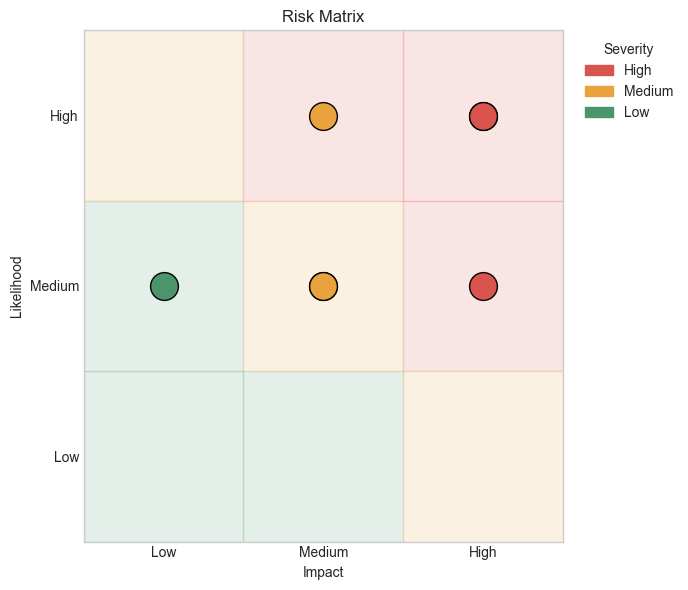

In [41]:
fig, ax = plt.subplots(figsize=(7, 6))
impact_map = {"Low": 0, "Medium": 1, "High": 2}
likelihood_map = {"Low": 0, "Medium": 1, "High": 2}
color_map = {"High": COLOR_ALT, "Medium": COLOR_WARN, "Low": COLOR_OK}

# background grid shading
for i in range(3):
    for j in range(3):
        sev = "Low"
        s = i + j
        if s >= 3:
            sev = "High"
        elif s >= 2:
            sev = "Medium"
        ax.add_patch(mpatches.Rectangle((j, i), 1, 1, color=color_map[sev], alpha=0.15))

for _, row in RISK_MATRIX.iterrows():
    x = impact_map[row["Impact"]] + 0.5
    y = likelihood_map[row["Likelihood"]] + 0.5
    ax.scatter(x, y, s=400, color=color_map[row["Severity"]], edgecolor="black", zorder=3)

ax.set_xticks([0.5, 1.5, 2.5]); ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_yticks([0.5, 1.5, 2.5]); ax.set_yticklabels(["Low", "Medium", "High"])
ax.set_xlabel("Impact")
ax.set_ylabel("Likelihood")
ax.set_title("Risk Matrix")
ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.grid(False)

handles = [mpatches.Patch(color=color_map[s], label=s) for s in ["High", "Medium", "Low"]]
ax.legend(handles=handles, title="Severity", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

---
# 9. Board Memo *(Automatically Generated)*

The cell below assembles a memo directly from the computed KPIs above — re-running this notebook on updated data regenerates the memo with no manual editing required.

In [42]:
memo_template = """
BOARD MEMO — SAAS REVENUE INTELLIGENCE
Generated: {gen_date}
{divider}

TO: Board of Directors
FROM: Revenue & Growth Analytics
RE: Q4 Revenue Health, Risk, and Investment Readiness Update

SUMMARY

The business operates on a verified ${arr} ARR base ({mrr} MRR) across
{active} active paying customers. Net Revenue Retention stands at {nrr}%
and Gross Revenue Retention at {grr}%, both below the healthy SaaS benchmark
of 100%+ / 90%+ respectively. Churn among revenue-generating customers is
{churn}%.

KEY FINDINGS

1. Retention, not expansion or downgrades, is the primary driver of revenue
   loss. plan_changes data shows zero contraction (no downgrades on record) —
   the gap is driven entirely by full customer churn.
2. The strongest churn signal identified (Notebook 3) is payment failure,
   an operationally addressable issue rather than a product or pricing one.
3. Revenue is concentrated: the top 10% of customers ({top10_n} accounts)
   generate {top10_share}% of historical revenue.
4. Composite Series C Readiness Score: {score}/100 ({tier}) — primarily
   held back by ARR scale and revenue concentration.

RECOMMENDED BOARD ACTION

Approve the five prioritized initiatives in Section 7 of the accompanying
analysis, totaling an estimated $75K-$130K in near-term investment, targeting
churn reduction, expansion revenue, and account concentration risk over the
next one to two quarters.

Full supporting analysis: Notebooks 1-4, SaaS Revenue Intelligence project.
"""

memo = memo_template.format(
    gen_date=datetime.now().strftime("%B %d, %Y"),
    divider="=" * 60,
    arr=f"{ARR:,.0f}",
    mrr=f"${MRR:,.0f}",
    active=f"{ACTIVE_CUSTOMERS:,}",
    nrr=f"{NRR:.1f}",
    grr=f"{GRR:.1f}",
    churn=f"{CHURN_RATE:.1f}",
    top10_n=f"{TOP10PCT_N:,}",
    top10_share=f"{TOP10PCT_REVENUE_SHARE:.1f}",
    score=f"{SERIES_C_SCORE:.1f}",
    tier=TIER,
)

print(memo)

with open("board_memo.txt", "w") as f:
    f.write(memo)
print("\nSaved to board_memo.txt")


BOARD MEMO — SAAS REVENUE INTELLIGENCE
Generated: July 11, 2026

TO: Board of Directors
FROM: Revenue & Growth Analytics
RE: Q4 Revenue Health, Risk, and Investment Readiness Update

SUMMARY

The business operates on a verified $2,458,218 ARR base ($204,852 MRR) across
5,469 active paying customers. Net Revenue Retention stands at 78.0%
and Gross Revenue Retention at 72.7%, both below the healthy SaaS benchmark
of 100%+ / 90%+ respectively. Churn among revenue-generating customers is
31.9%.

KEY FINDINGS

1. Retention, not expansion or downgrades, is the primary driver of revenue
   loss. plan_changes data shows zero contraction (no downgrades on record) —
   the gap is driven entirely by full customer churn.
2. The strongest churn signal identified (Notebook 3) is payment failure,
   an operationally addressable issue rather than a product or pricing one.
3. Revenue is concentrated: the top 10% of customers (802 accounts)
   generate 38.4% of historical revenue.
4. Composite Series C

---
# 10. Executive Dashboard Summary *(One Page)*

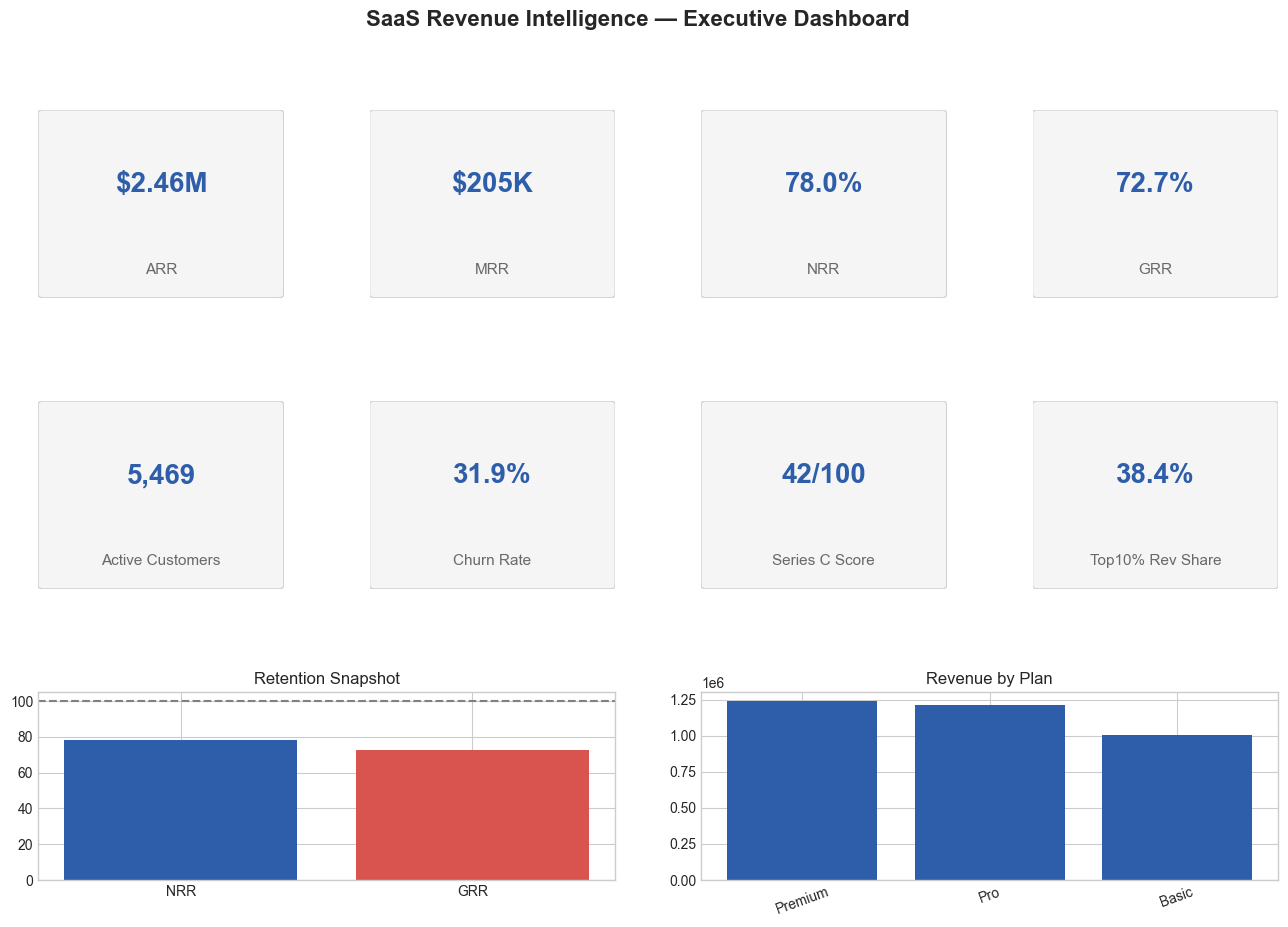

Saved to executive_dashboard_summary.png


In [43]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.35)

kpi_cells = [
    ("ARR", f"${ARR/1e6:.2f}M"),
    ("MRR", f"${MRR/1e3:.0f}K"),
    ("NRR", f"{NRR:.1f}%"),
    ("GRR", f"{GRR:.1f}%"),
    ("Active Customers", f"{ACTIVE_CUSTOMERS:,}"),
    ("Churn Rate", f"{CHURN_RATE:.1f}%"),
    ("Series C Score", f"{SERIES_C_SCORE:.0f}/100"),
    ("Top10% Rev Share", f"{TOP10PCT_REVENUE_SHARE:.1f}%"),
]
for i, (label, value) in enumerate(kpi_cells):
    ax = fig.add_subplot(gs[0, i % 4]) if i < 4 else fig.add_subplot(gs[1, i % 4])
    ax.axis("off")
    ax.text(0.5, 0.6, value, ha="center", va="center", fontsize=20, fontweight="bold", color=COLOR_MAIN)
    ax.text(0.5, 0.15, label, ha="center", va="center", fontsize=11, color="dimgray")
    ax.add_patch(mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle="round,pad=0.02",
                                          linewidth=1, edgecolor="lightgray", facecolor="whitesmoke", zorder=-1))

ax_ret = fig.add_subplot(gs[2, :2])
ax_ret.bar(["NRR", "GRR"], [NRR, GRR], color=[COLOR_MAIN, COLOR_ALT])
ax_ret.axhline(100, color="gray", linestyle="--")
ax_ret.set_title("Retention Snapshot")

ax_plan = fig.add_subplot(gs[2, 2:])
ax_plan.bar(REV_BY_PLAN.index, REV_BY_PLAN.values, color=COLOR_MAIN)
ax_plan.set_title("Revenue by Plan")
ax_plan.tick_params(axis="x", rotation=20)

fig.suptitle("SaaS Revenue Intelligence — Executive Dashboard", fontsize=16, fontweight="bold", y=0.98)
plt.savefig("executive_dashboard_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to executive_dashboard_summary.png")

---
# 11. Final Business Conclusion

In [44]:
print(
    f"""
FINAL BUSINESS CONCLUSION
{'='*60}
The business has a real, defensible ${ARR:,.0f} ARR base and {ACTIVE_CUSTOMERS:,}
active paying customers, but retention economics are currently net-negative
(NRR {NRR:.1f}%, GRR {GRR:.1f}%), and growth is being funded almost entirely
by new customer acquisition rather than expansion of the existing base.

The path to Series C readiness (current composite score: {SERIES_C_SCORE:.1f}/100,
'{TIER}') runs through two levers this analysis identifies as both material
and addressable: (1) reducing churn — concentrated in early tenure and tied
to payment failures — and (2) reducing revenue concentration risk in the
top decile of accounts. Both are directly actionable via the five board
recommendations in Section 7, at a combined estimated cost of $75K-$130K
against a retention and expansion upside materially larger than that spend.
"""
)


FINAL BUSINESS CONCLUSION
The business has a real, defensible $2,458,218 ARR base and 5,469
active paying customers, but retention economics are currently net-negative
(NRR 78.0%, GRR 72.7%), and growth is being funded almost entirely
by new customer acquisition rather than expansion of the existing base.

The path to Series C readiness (current composite score: 42.4/100,
'Early Stage — Gaps to Close') runs through two levers this analysis identifies as both material
and addressable: (1) reducing churn — concentrated in early tenure and tied
to payment failures — and (2) reducing revenue concentration risk in the
top decile of accounts. Both are directly actionable via the five board
recommendations in Section 7, at a combined estimated cost of $75K-$130K
against a retention and expansion upside materially larger than that spend.

